✓ Jesolo: 15.818 km di costa


C:\Users\01and\AppData\Local\Temp\ipykernel_26840\1067924129.py:77: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  ax.legend(loc="lower right", framealpha=0.9)


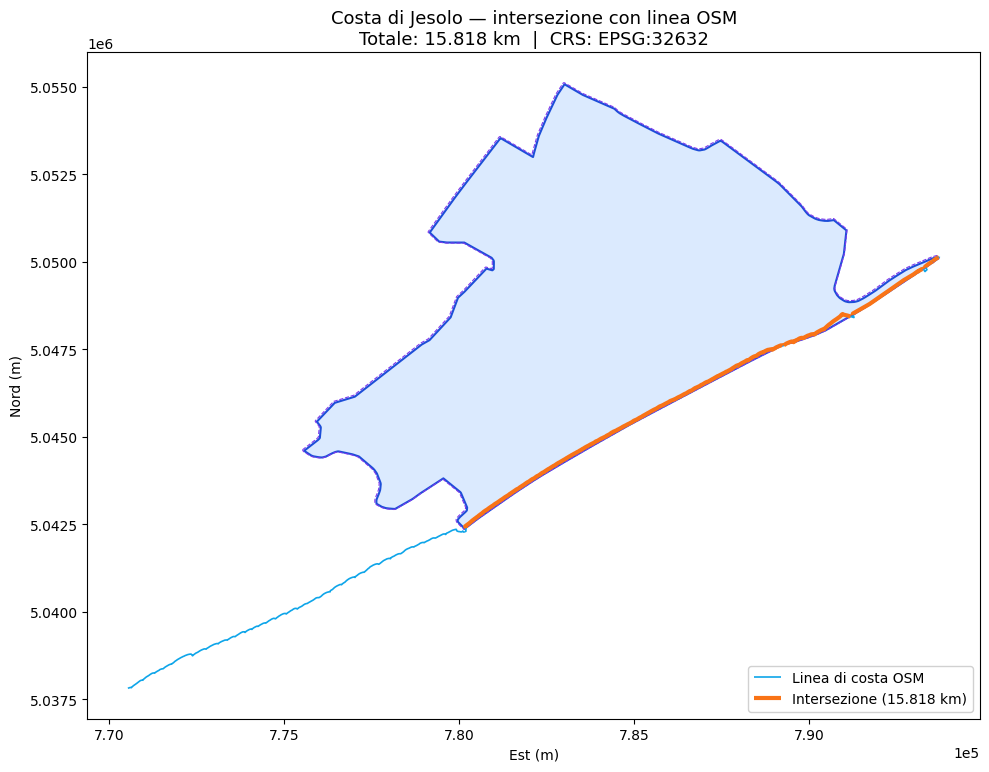

In [2]:
import geopandas as gpd
import matplotlib.pyplot as plt
from src.utils.openstreetmap_manager import (
    OpenStreetMap,
    _extract_lines,
    _normalize_name,
    METRIC_CRS,
    BOUNDARY_BUFFER_METERS,
    COMUNE_NAME_FIELD,
    COD_ISTAT_FIELD,
)

# ── parametri ──────────────────────────────────────────────────────────────────
COMUNI_SHP        = "data/input/ISTAT/Com01012024_g/Com01012024_g_WGS84.shp"
COASTLINE_GEOJSON = "data/input/OpenStreetMap/coast_line.geojson"
COMUNE_TARGET     = "Jesolo"

# ── carica dati ────────────────────────────────────────────────────────────────
osm = OpenStreetMap()
osm.load_municipalities(COMUNI_SHP)  # inizializza _comuni_shp_path, il DataFrame non serve qui

# La geometria va letta direttamente dallo shapefile e proiettata in metrico
comuni_gdf = gpd.read_file(COMUNI_SHP).to_crs(METRIC_CRS)

mask       = comuni_gdf[COMUNE_NAME_FIELD].apply(_normalize_name) == _normalize_name(COMUNE_TARGET)
comune_row = comuni_gdf[mask]
assert not comune_row.empty, f"Comune '{COMUNE_TARGET}' non trovato"

coast = gpd.read_file(COASTLINE_GEOJSON)
if coast.crs is None:
    coast = coast.set_crs("EPSG:4326")
coast = coast.to_crs(METRIC_CRS)
coast["geometry"] = coast.geometry.apply(
    lambda g: g.boundary if g.geom_type in ("Polygon", "MultiPolygon") else g
)
coast = coast[coast.geom_type.isin(["LineString", "MultiLineString"])]

# ── intersezione costa × comune ────────────────────────────────────────────────
comune_geom     = comune_row.geometry.values[0]
comune_buffered = comune_geom.buffer(BOUNDARY_BUFFER_METERS)

coast_clip = coast[coast.intersects(comune_buffered)].copy()
coast_clip["geometry"] = coast_clip.geometry.intersection(comune_buffered).apply(_extract_lines)
coast_intersection = coast_clip[coast_clip["geometry"].notna()].copy()

km_totali = coast_intersection.geometry.length.sum() / 1000
print(f"✓ {COMUNE_TARGET}: {km_totali:.3f} km di costa")

# ── plot ───────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 8))

gpd.GeoSeries([comune_geom], crs=METRIC_CRS).plot(
    ax=ax, facecolor="#dbeafe", edgecolor="#1d4ed8",
    linewidth=1.5, zorder=1, label=COMUNE_TARGET
)
gpd.GeoSeries([comune_buffered], crs=METRIC_CRS).plot(
    ax=ax, facecolor="none", edgecolor="#7c3aed",
    linewidth=0.8, linestyle="--", zorder=2,
    label=f"Buffer {BOUNDARY_BUFFER_METERS} m"
)
coast[coast.intersects(comune_buffered.envelope)].plot(
    ax=ax, color="#0ea5e9", linewidth=1.2, zorder=3, label="Linea di costa OSM"
)
if not coast_intersection.empty:
    gpd.GeoDataFrame(coast_intersection, crs=METRIC_CRS).plot(
        ax=ax, color="#f97316", linewidth=3, zorder=4,
        label=f"Intersezione ({km_totali:.3f} km)"
    )

ax.set_title(
    f"Costa di {COMUNE_TARGET} — intersezione con linea OSM\n"
    f"Totale: {km_totali:.3f} km  |  CRS: {METRIC_CRS}",
    fontsize=13
)
ax.set_xlabel("Est (m)")
ax.set_ylabel("Nord (m)")
ax.legend(loc="lower right", framealpha=0.9)
ax.ticklabel_format(style="sci", scilimits=(0, 0), axis="both")
plt.tight_layout()
plt.show()

✓ Levico Terme: 6.474 km di costa lago


C:\Users\01and\AppData\Local\Temp\ipykernel_26840\321117484.py:74: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  ax.legend(loc="lower right", framealpha=0.9)


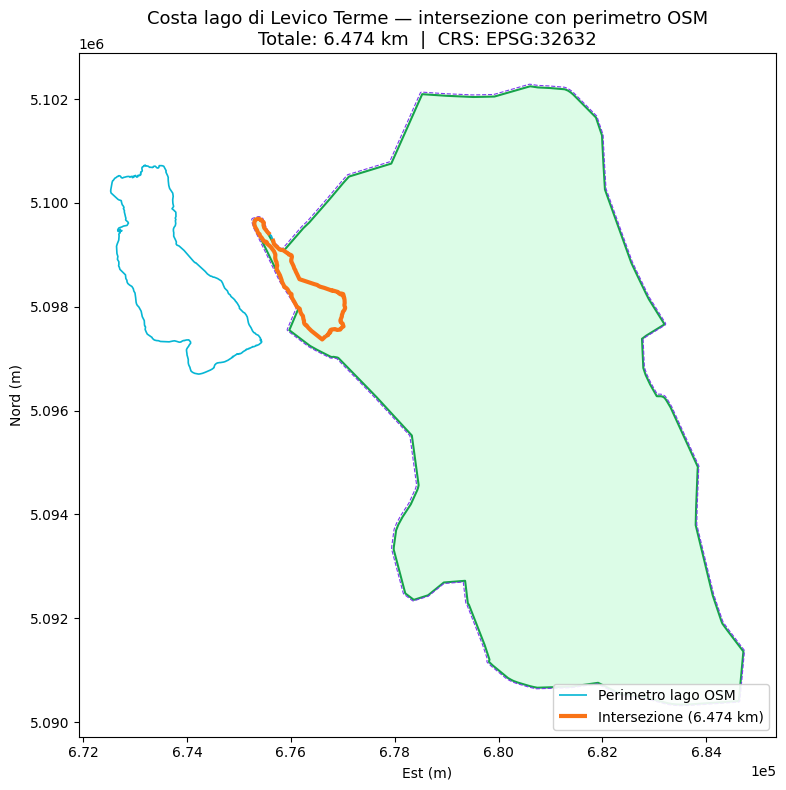

In [3]:
import geopandas as gpd
import matplotlib.pyplot as plt
from src.utils.openstreetmap_manager import (
    OpenStreetMap,
    _extract_lines,
    _normalize_name,
    METRIC_CRS,
    BOUNDARY_BUFFER_METERS,
    COMUNE_NAME_FIELD,
)

# ── parametri ──────────────────────────────────────────────────────────────────
COMUNI_SHP    = "data/input/ISTAT/Com01012024_g/Com01012024_g_WGS84.shp"
LAKE_GEOJSON  = "data/input/OpenStreetMap/lake_coast.geojson"
COMUNE_TARGET = "Levico Terme"

# ── carica dati ────────────────────────────────────────────────────────────────
osm = OpenStreetMap()
osm.load_municipalities(COMUNI_SHP)  # inizializza _comuni_shp_path

comuni_gdf = gpd.read_file(COMUNI_SHP).to_crs(METRIC_CRS)
mask       = comuni_gdf[COMUNE_NAME_FIELD].apply(_normalize_name) == _normalize_name(COMUNE_TARGET)
comune_row = comuni_gdf[mask]
assert not comune_row.empty, f"Comune '{COMUNE_TARGET}' non trovato"

lake = gpd.read_file(LAKE_GEOJSON)
if lake.crs is None:
    lake = lake.set_crs("EPSG:4326")
lake = lake.to_crs(METRIC_CRS)
lake["geometry"] = lake.geometry.apply(
    lambda g: g.boundary if g.geom_type in ("Polygon", "MultiPolygon") else g
)
lake = lake[lake.geom_type.isin(["LineString", "MultiLineString"])]

# ── intersezione lago × comune ─────────────────────────────────────────────────
comune_geom     = comune_row.geometry.values[0]
comune_buffered = comune_geom.buffer(BOUNDARY_BUFFER_METERS)

lake_clip = lake[lake.intersects(comune_buffered)].copy()
lake_clip["geometry"] = lake_clip.geometry.intersection(comune_buffered).apply(_extract_lines)
lake_intersection = lake_clip[lake_clip["geometry"].notna()].copy()

km_totali = lake_intersection.geometry.length.sum() / 1000
print(f"✓ {COMUNE_TARGET}: {km_totali:.3f} km di costa lago")

# ── plot ───────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 8))

gpd.GeoSeries([comune_geom], crs=METRIC_CRS).plot(
    ax=ax, facecolor="#dcfce7", edgecolor="#16a34a",
    linewidth=1.5, zorder=1, label=COMUNE_TARGET
)
gpd.GeoSeries([comune_buffered], crs=METRIC_CRS).plot(
    ax=ax, facecolor="none", edgecolor="#7c3aed",
    linewidth=0.8, linestyle="--", zorder=2,
    label=f"Buffer {BOUNDARY_BUFFER_METERS} m"
)
lake[lake.intersects(comune_buffered.envelope)].plot(
    ax=ax, color="#06b6d4", linewidth=1.2, zorder=3, label="Perimetro lago OSM"
)
if not lake_intersection.empty:
    gpd.GeoDataFrame(lake_intersection, crs=METRIC_CRS).plot(
        ax=ax, color="#f97316", linewidth=3, zorder=4,
        label=f"Intersezione ({km_totali:.3f} km)"
    )

ax.set_title(
    f"Costa lago di {COMUNE_TARGET} — intersezione con perimetro OSM\n"
    f"Totale: {km_totali:.3f} km  |  CRS: {METRIC_CRS}",
    fontsize=13
)
ax.set_xlabel("Est (m)")
ax.set_ylabel("Nord (m)")
ax.legend(loc="lower right", framealpha=0.9)
ax.ticklabel_format(style="sci", scilimits=(0, 0), axis="both")
plt.tight_layout()
plt.show()